In [27]:
import numpy as np 
import matplotlib.pyplot as plt
import scipy 
import scienceplots
import matplotlib 
plt.style.use(['science'])
matplotlib.rcParams['font.size'] = 30

In [2]:
# Constants

G = 6.67430e-11  # Gravitational constant in m^3 kg^-1 s^-2
c = 299792458  # Speed of light in m/s
M_sun = 1.9885e30  # Mass of the Sun in kg
pc = 3.0856775814913673e16  # Parsec in meters

YRSID_SI = 3.15576e7  # One year in seconds

In [3]:
# Newtonian chirp

def Amp(Mc,D_L,f):
    """
    Calculate the amplitude of the gravitational wave signal (time domain) for a binary system using the Newtonian approximation.
    
    Parameters:
    Mc : float
        Chirp mass in solar masses.
    D_L : float
        Luminosity distance in parsecs.
    f : array
        GW Frequency (as a function of time) in Hz.
        
    Returns:
    float
        Amplitude of the gravitational wave signal.
    """
    amp_prefactor = (4*G**(5/3)*Mc**(5/3)*np.pi**(2/3))/(c**4 * D_L)

    amp = amp_prefactor * f**(2/3)

    return amp

def freq(Mc,t_c,t):
    """
    Calculate the frequency of the gravitational wave signal for a binary system using the Newtonian approximation, as a function of time 
    
    Parameters:
    Mc : float
        Chirp mass in solar masses.
    t_c : float
        Coalescence time in seconds.
    t : array
        Time in seconds.
        
    Returns:
    array
        Frequency of the gravitational wave signal.
    """
    constant_prefactor = 5**(3/8) / (8*np.pi) * c**(15/8)/(G**(5/8))

    freq = constant_prefactor * (Mc**(-5/8)) * ((t_c - t)**(-3/8))
                                            
    return freq

def time_to_merger(Mc,f):
    """
    Calculate the time to merger for a binary system using the Newtonian approximation from a given frequency 
    
    Parameters:
    Mc : float
        Chirp mass in solar masses.
    f : array
        Frequency of the gravitational wave signal in Hz.
        
    Returns:
    float
        Time to merger in seconds.
    """
    constant_prefactor = 5/(8*np.pi)**(8/3)*c**5/G**(5/3)
    t_c = constant_prefactor * (Mc**(-5/3)) * (f**(-8/3))
    return t_c

def phase(Mc,t,tc,phi_c):
    """
    Calculate the phase of the gravitational wave signal for a binary system using the Newtonian approximation.
    
    Parameters:
    Mc : float
        Chirp mass in solar masses.
    t : array
        Time in seconds.
    tc : float
        Coalescence time in seconds.
    phi_c : float
        Phase at coalescence in radians.
        
    Returns:
    array
        Phase of the gravitational wave signal.
    """
    constant_prefactor = -2/(5**(5/8))*c**(15/8)/G**(5/8) 
    
    phase = constant_prefactor * (Mc**(-5/8)) * ((tc - t)**(5/8)) + phi_c
    
    return phase


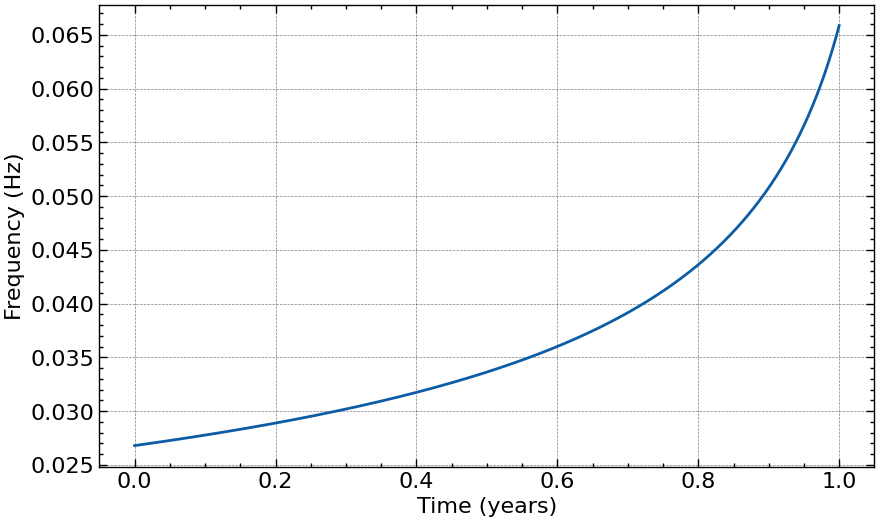

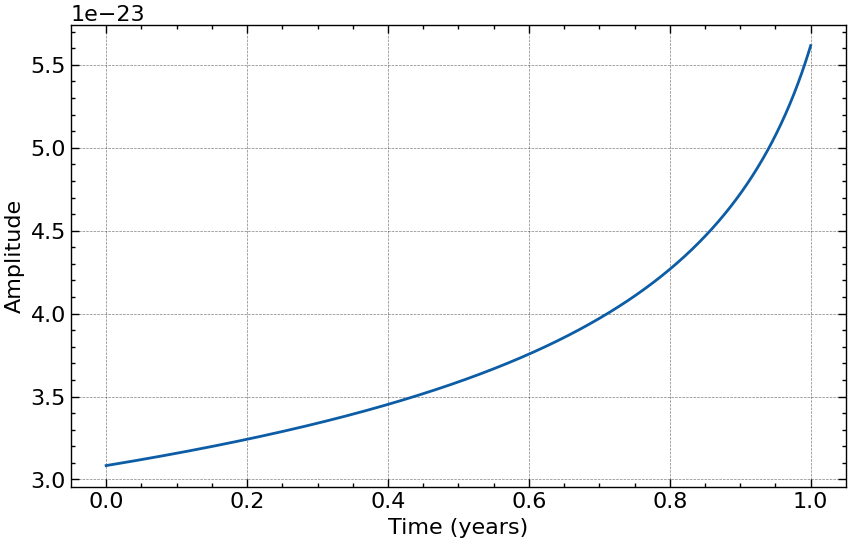

In [4]:
# Params of a binary system 

Mc = 30* M_sun  # Chirp mass in kg
D_L = 100*1.e+6 * pc  # Luminosity distance in meters
tc = 1.1 * YRSID_SI  # Coalescence time in seconds (WE ARE SETTING THIS FOR THIS CASE)

times = np.arange(0, YRSID_SI, 5)  # Time in seconds

plt.figure(figsize=(10, 6))

freqs = freq(Mc, tc, times)  # Frequency in Hz

plt.plot(times/YRSID_SI, freqs, label='Frequency')
plt.xlabel('Time (years)')
plt.ylabel('Frequency (Hz)')
plt.show()

Amp_ = Amp(Mc, D_L, freqs)  # Amplitude (dimensionless)
plt.figure(figsize=(10, 6))
plt.plot(times/YRSID_SI, Amp_, label='Amplitude')
plt.xlabel('Time (years)')
plt.ylabel('Amplitude')
plt.show()




/Users/diganta/Desktop/Papers/Full_search/venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


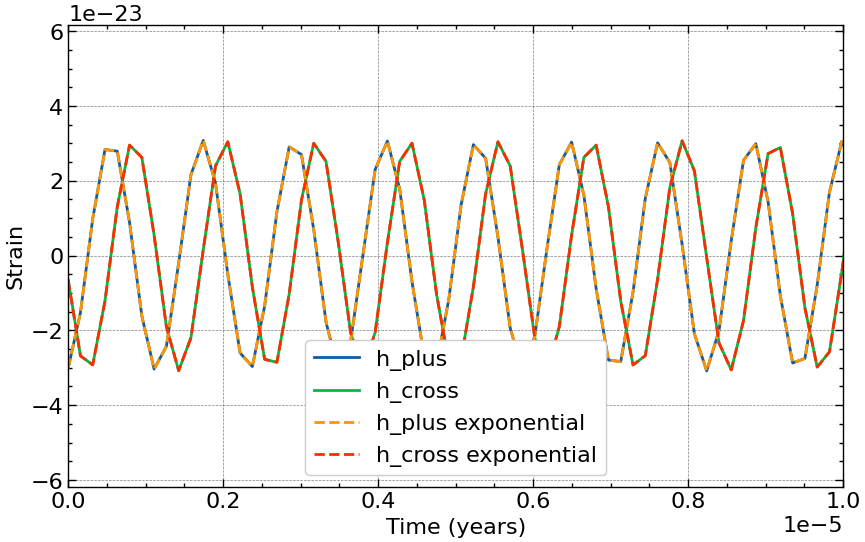

In [5]:
# Build waveform 

phi_c = 0  # Phase at coalescence in radians
phases = phase(Mc, times, tc, phi_c)  # Phase in radians

h_plus_exp = np.real(Amp_ * np.exp(1j*phases))
h_cross_exp = np.imag(Amp_ * np.exp(1j*phases))

h_plus = Amp_ * np.cos(phases)
h_cross = Amp_ * np.sin(phases)

plt.figure(figsize=(10, 6))
plt.plot(times/YRSID_SI, h_plus, label='h_plus')
plt.plot(times/YRSID_SI, h_cross, label='h_cross')

plt.plot(times/YRSID_SI, h_plus_exp, label='h_plus exponential',linestyle='--')
plt.plot(times/YRSID_SI, h_cross_exp, label='h_cross exponential',linestyle='--')

plt.xlim(0,0.00001)
plt.xlabel('Time (years)')
plt.ylabel('Strain')
plt.legend()
plt.show()

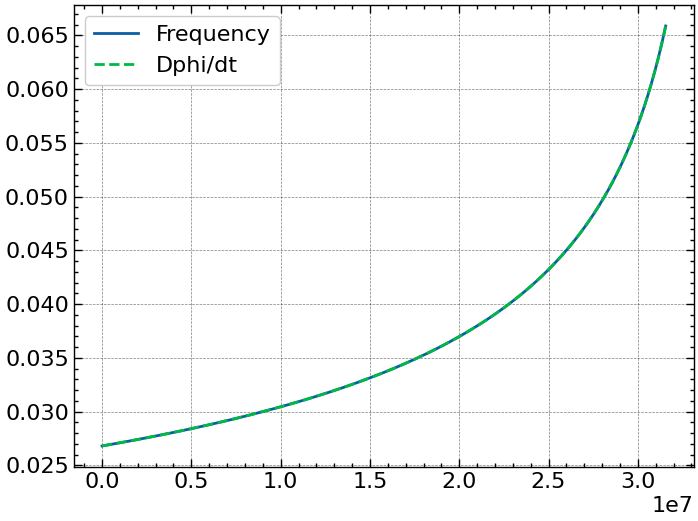

In [6]:
dt = 5
f_derived = (phases[1:]-phases[:-1])/dt *1/(2*np.pi)

central_times = (times[1:] + times[:-1])/2
plt.plot(times, freqs, label='Frequency')
plt.plot(central_times,f_derived,label='Dphi/dt',linestyle='--')
plt.legend()
plt.show()



/Users/diganta/Desktop/Papers/Full_search/venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


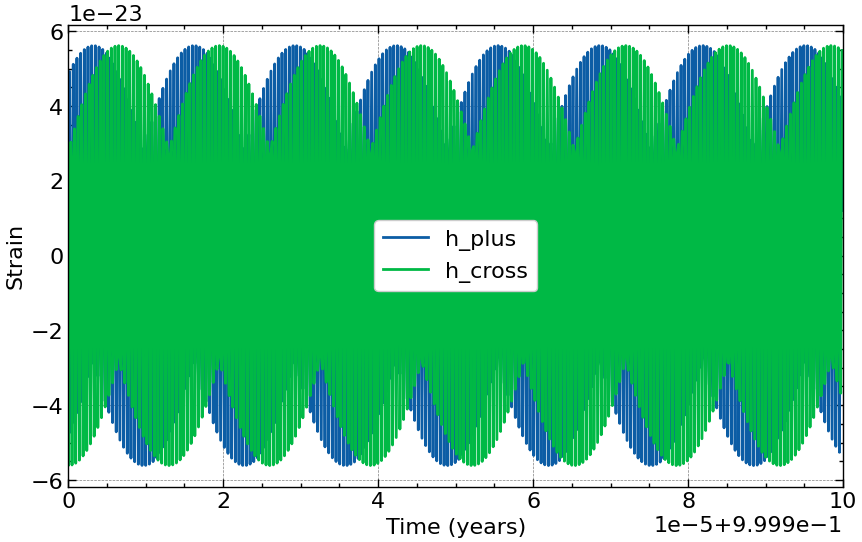

In [7]:

plt.figure(figsize=(10, 6))
plt.plot(times/YRSID_SI, h_plus, label='h_plus')
plt.plot(times/YRSID_SI, h_cross, label='h_cross')
plt.xlim(0.9999,1.0)
plt.xlabel('Time (years)')
plt.ylabel('Strain')
plt.legend()
plt.show()


In [8]:
times[1]-times[0]

5.0

In [9]:
window = scipy.signal.windows.tukey(len(h_plus), alpha=0.1)


h_plus_fft = np.fft.rfft(h_plus* window)
h_cross_fft = np.fft.rfft(h_cross * window)

fft_freqs = np.fft.rfftfreq(len(times), d=(times[1]-times[0]))  # Frequency bins for FFT

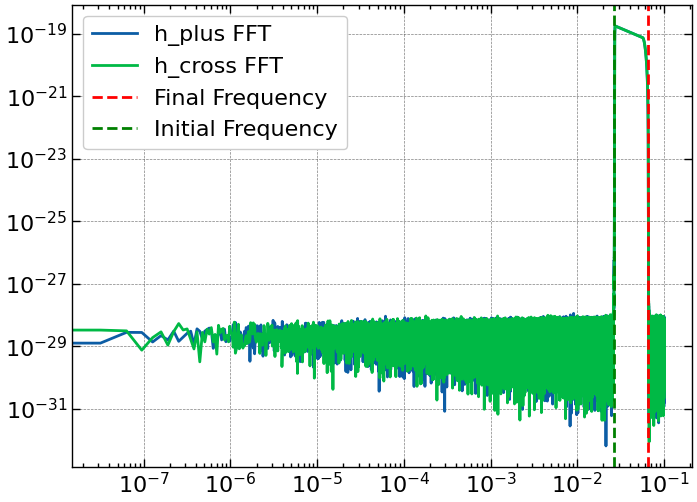

In [10]:
plt.loglog(fft_freqs, np.abs(h_plus_fft), label='h_plus FFT')
plt.loglog(fft_freqs, np.abs(h_cross_fft), label='h_cross FFT')

plt.axvline(freqs[-1], color='r', linestyle='--', label='Final Frequency')
plt.axvline(freqs[0], color='g', linestyle='--', label='Initial Frequency')
plt.legend()
plt.show()

Fresnel pre-requisites. (We already have A(t), f(t) and phi(t) we just need f_dot(t))

In [11]:
def freq(Mc,t_c,t):
    """
    Calculate the frequency of the gravitational wave signal for a binary system using the Newtonian approximation, as a function of time 
    
    Parameters:
    Mc : float
        Chirp mass in solar masses.
    t_c : float
        Coalescence time in seconds.
    t : array
        Time in seconds.
        
    Returns:
    array
        Frequency of the gravitational wave signal.
    """
    constant_prefactor = 5**(3/8) / (8*np.pi) * c**(15/8)/(G**(5/8))

    freq = constant_prefactor * (Mc**(-5/8)) * ((t_c - t)**(-3/8))
                                            
    return freq

def f_dot(Mc,t_c,t):
    """Calculate the time derivative of the frequency."""
    constant_prefactor = 5**(3/8) / (8*np.pi) * c**(15/8)/(G**(5/8))
    fdot = constant_prefactor * (3/8) * (Mc**(-5/8)) * ((t_c - t)**(-11/8))
    return fdot

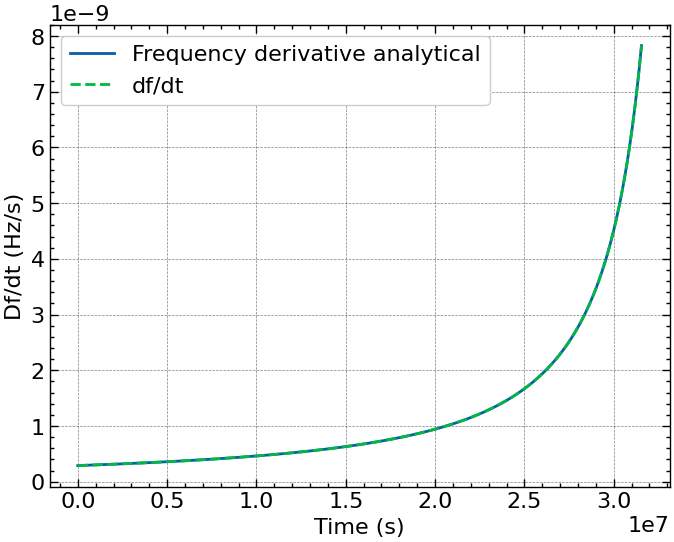

In [12]:
f_dot_derived = (freqs[1:]-freqs[:-1])/dt

central_times = (times[1:] + times[:-1])/2

f_dot_analytical = f_dot(Mc, tc, central_times)

plt.plot(central_times, f_dot_analytical, label='Frequency derivative analytical')
plt.plot(central_times,f_dot_derived,label='df/dt',linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Df/dt (Hz/s)')
plt.legend()
plt.show()



/var/folders/8g/7279dvmd20vd_b85_lr8pfh80000gp/T/ipykernel_3163/1559295532.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


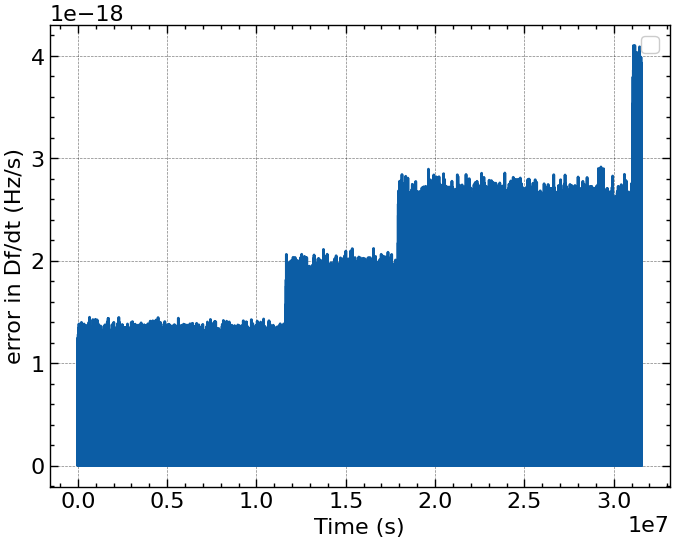

In [13]:
plt.plot(central_times, np.abs(f_dot_analytical-f_dot_derived))
plt.xlabel('Time (s)')
plt.ylabel('error in Df/dt (Hz/s)')
plt.legend()
plt.show()


In [14]:
f_dot_analytical

array([2.89553131e-10, 2.89553188e-10, 2.89553246e-10, ...,
       7.82780238e-09, 7.82781943e-09, 7.82783649e-09])

In [15]:

Mc = 30* M_sun  # Chirp mass in kg
D_L = 100*1.e+6 * pc  # Luminosity distance in meters
tc = 1.1 * YRSID_SI  # Coalescence time in seconds (WE ARE SETTING THIS FOR THIS CASE)

times = np.arange(0, YRSID_SI, 5)  # Time in seconds

In [16]:
def v(f_dot_0,t_0,t_1,f,f_0):
    fresnel_argument = np.sqrt(2*f_dot_0)*((t_1-t_0) + (f_0-f)/f_dot_0)
    return fresnel_argument

def h_fresnel(Mc,D_L,tc,phi_c,t_0,t_1,freqs,bins=10):
    '''
    Fresnel waveform in an SFT time segment from t_0 to t_1 evaluated at frequency f.
    '''
    # Evaluate everything at the beginning of the bin, A_0, f_0, t_0 etc 
    f_0 = freq(Mc,tc,t_0)
    phase_0 = phase(Mc,t_0,tc,phi_c)
    Amp_0 = Amp(Mc,D_L,f_0)*1/2 # 1/2 factor for single polarization
    f_dot_0 = f_dot(Mc,tc,t_0)
    
    closest_f_index = np.argmin(np.abs(freqs-f_0))
    
    # Select frequency bins around f_0
    f = freqs[closest_f_index-bins:closest_f_index+bins]    

    h_prefactor = Amp_0*np.exp(1j*phase_0)/np.sqrt(2*f_dot_0) * np.exp(-1j*np.pi*((f_0 - f)**2)/f_dot_0)

    # Fresnel integral stuff
    v_nm_end = v(f_dot_0,t_0,t_1,f,f_0)
    v_nm_begin = v(f_dot_0,t_0,t_0,f,f_0)
    S_vn_end, C_vn_end = scipy.special.fresnel(v_nm_end)
    S_vn_begin, C_vn_begin = scipy.special.fresnel(v_nm_begin)

    I = C_vn_end - C_vn_begin + 1j*(S_vn_end - S_vn_begin)

    # res = []

    # for fr in f: 
    #     h_prefactor = Amp_0*np.exp(1j*phase_0)/np.sqrt(2*f_dot_0) * np.exp(-np.pi*((f_0 - fr)**2)/f_dot_0)

    #     # Fresnel integral stuff
    #     v_nm_end = v(f_dot_0,t_0,t_1,fr,f_0)
    #     v_nm_begin = v(f_dot_0,t_0,t_0,fr,f_0)
    #     C_vn_end, S_vn_end = _fresnel(v_nm_end)#scipy.special.fresnel(v_nm_end)
    #     C_vn_begin, S_vn_begin = _fresnel(v_nm_begin)#scipy.special.fresnel(v_nm_begin)

    #     I = C_vn_end - C_vn_begin + 1j*(S_vn_end - S_vn_begin)
    #     res.append(h_prefactor * I)

    return h_prefactor * I,f
    # return np.array(res),f


In [17]:
def setup_tf_grid(T,
                  dt, 
                  dT):
    '''
    Sets up time-frequency grid for time-frequency domain calculations. 

    Args:
        T (float): Total observation time (s) 
        dt (float): Sampling time (s)
        dT (float): Time segment duration (s)
    Returns:
        t_grid (jax.numpy.array): Time grid (s)
        f_grid (jax.numpy.array): Frequency grid (Hz)
    '''

    print("Setting up time-frequency grid...")
    print(f"Total observation time: {T} s")

    nT = int(T/dT) # length of each time chunk
    print(f"Number of time segments: {nT}")

    t_grid = np.arange(nT)*dT
    # Frequency resolution 
    dF =f_min= (1/dT)
    f_max = 1/(dt)/ 2 # Nyquist frequency 

    nF = int((f_max - f_min) / dF) + 1 # frequency bins per segment
    
    # Frequency grid (neglecting DC component)
    f_grid = np.arange(1,nF+1) * dF  # segment frequencies
    # Time grid
    t_grid = np.arange(nT) * dT

    return(t_grid,f_grid)

In [18]:
t_grid,f_grid = setup_tf_grid(times[-1],# around 1 year
              5,# Cadence,
              3*60*60,#dT,
              )

Setting up time-frequency grid...
Total observation time: 31557595.0 s
Number of time segments: 2921


In [19]:
f_grid

array([9.25925926e-05, 1.85185185e-04, 2.77777778e-04, ...,
       9.98148148e-02, 9.99074074e-02, 1.00000000e-01])

In [20]:
dt

5

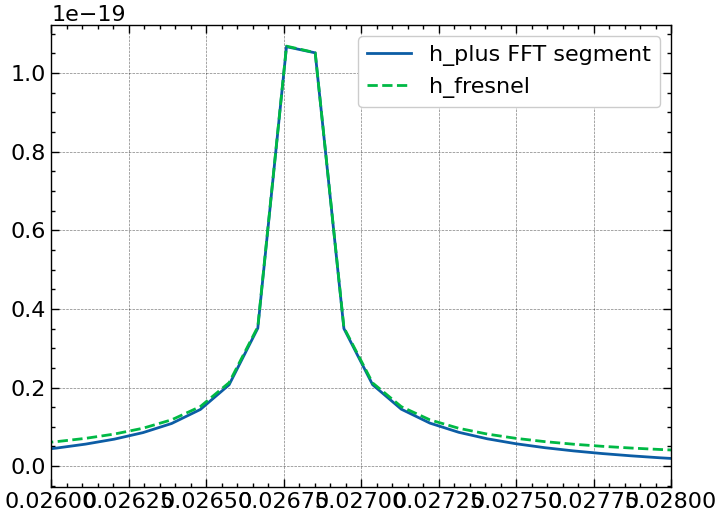

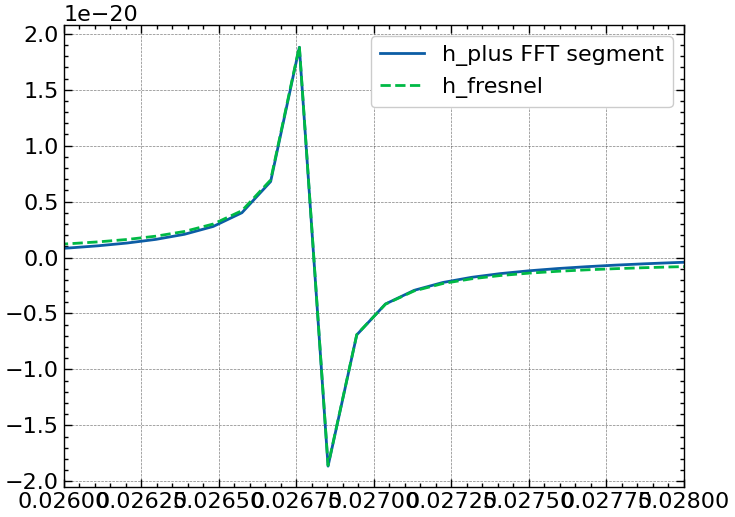

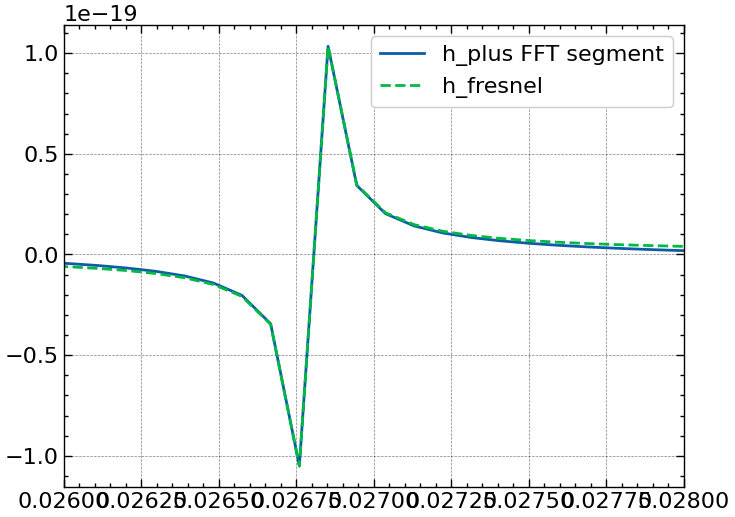

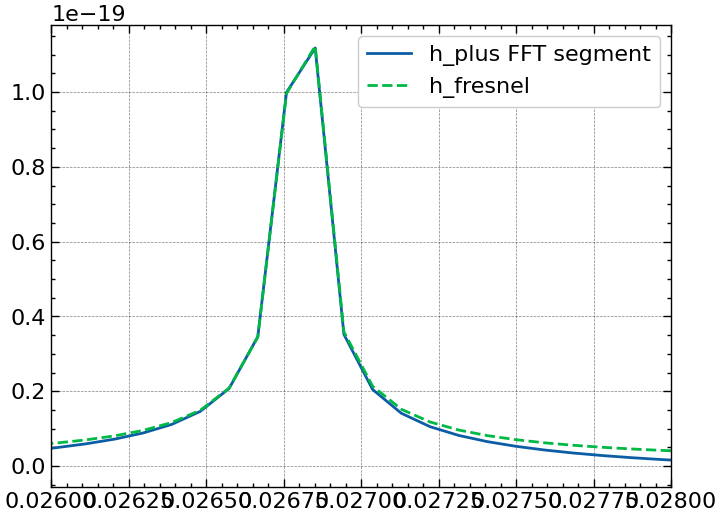

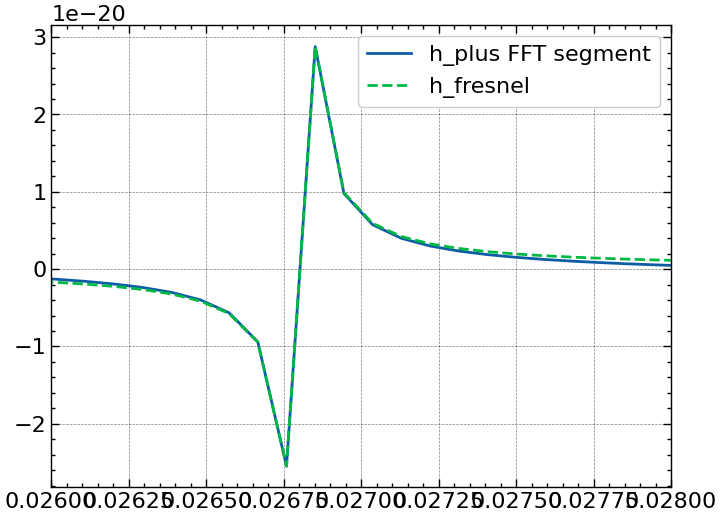

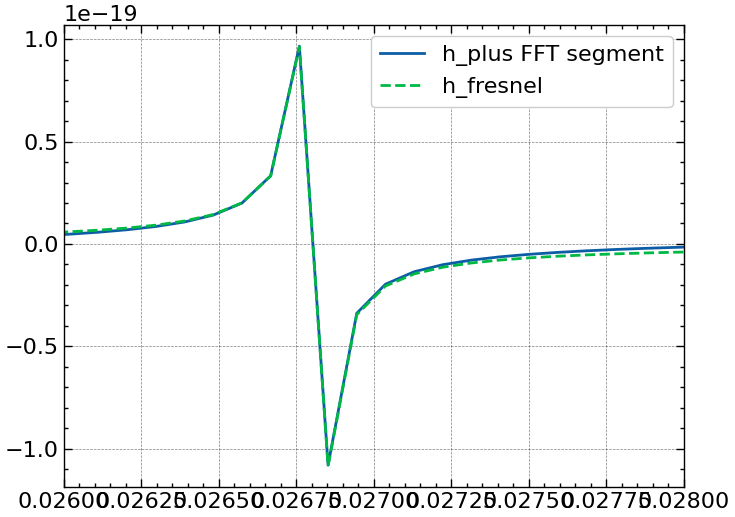

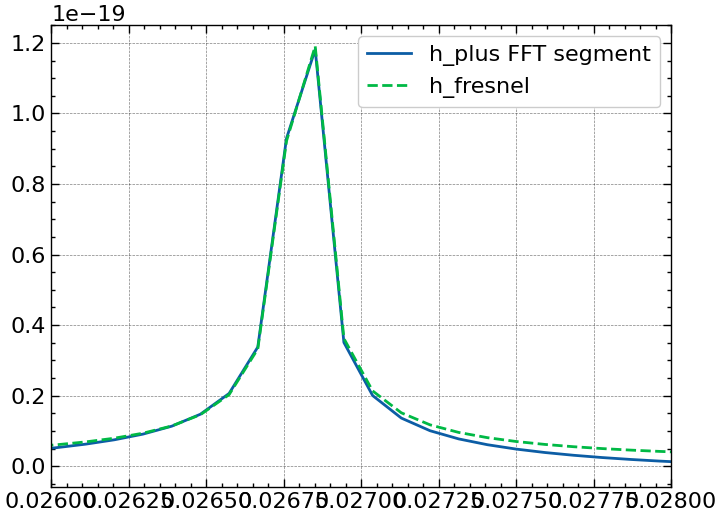

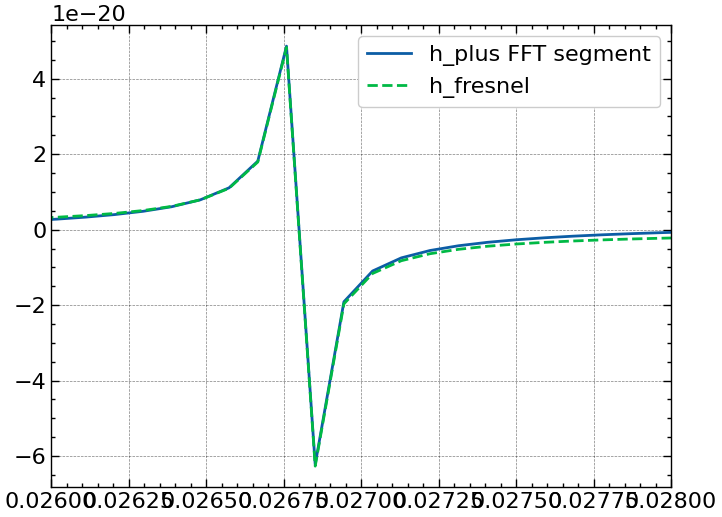

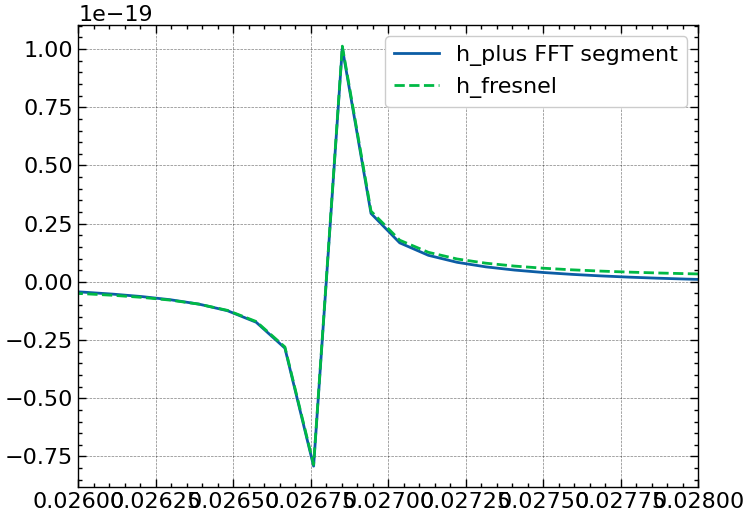

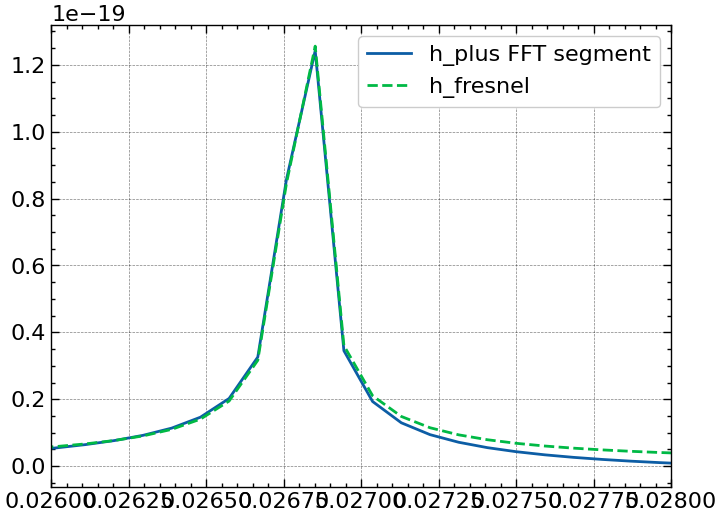

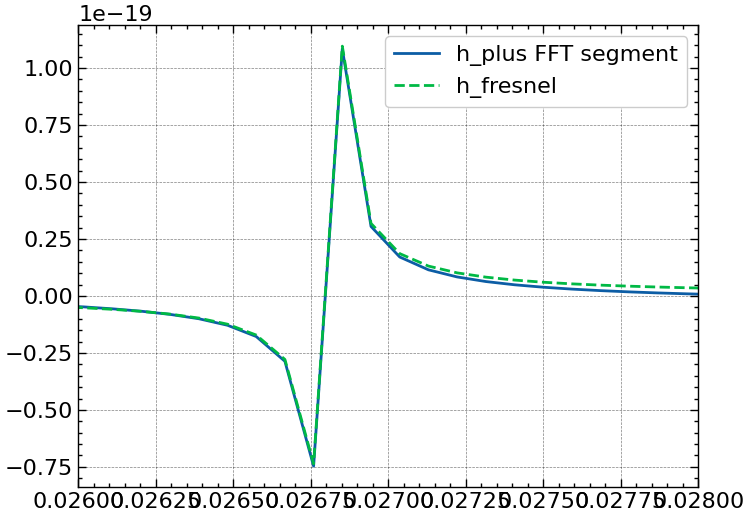

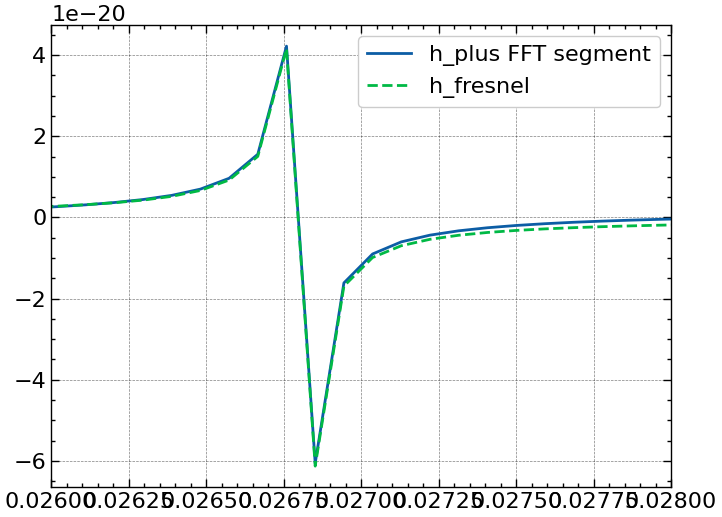

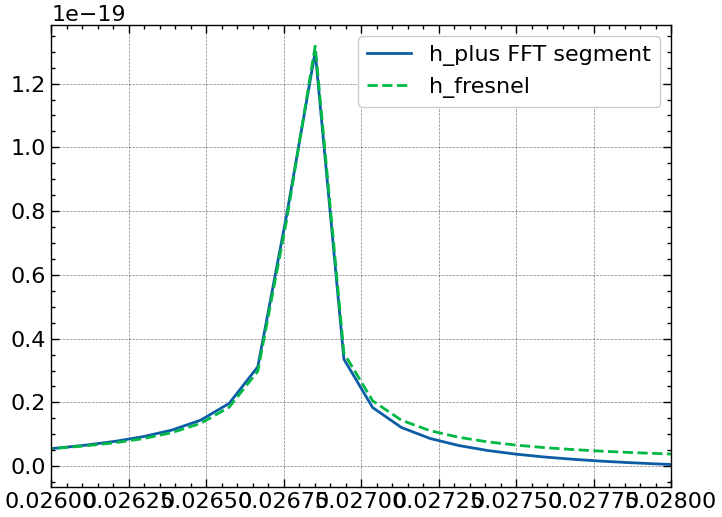

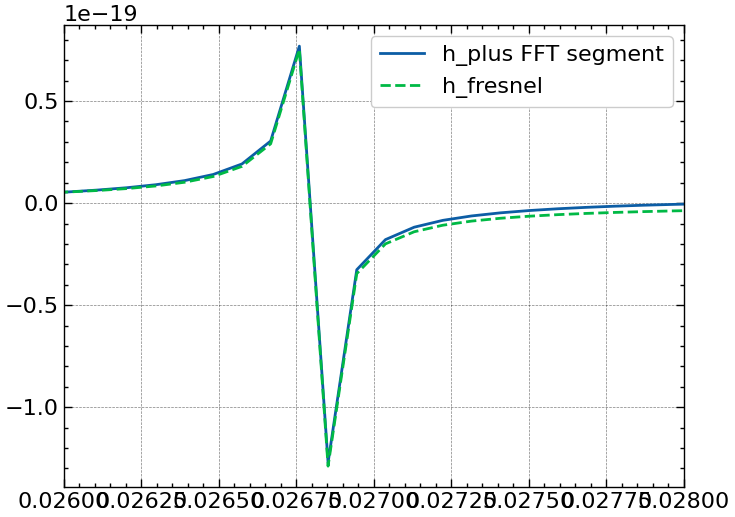

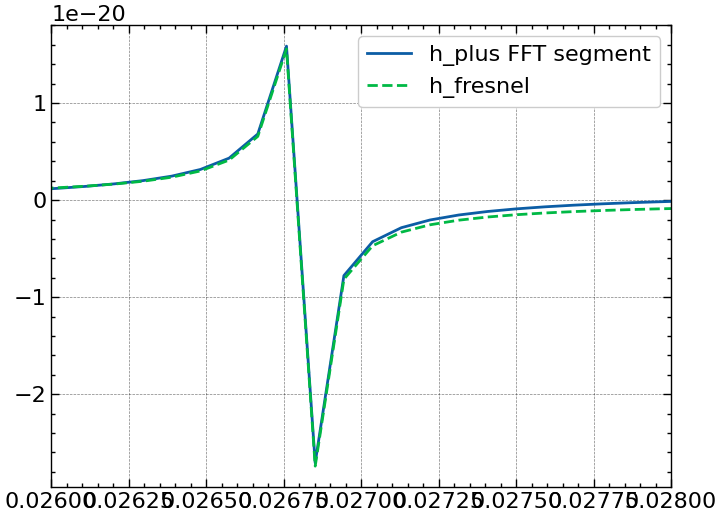

In [21]:
# Individually take fresnel representations of h_plus and h_cross in each time segment 

t_grid

# for time_index in range(t_grid.size-1):
for time_index in range(5):
    t_0 = t_grid[time_index]
    t_1 = t_grid[time_index+1]
    # Take FFT of h(t) in this segment, this is the ground truth we are trying to reproduce
    h_plus_segment = h_plus[(times >= t_0) & (times < t_1)]
    # h_cross_segment = h_cross[(times >= t_0) & (times < t_1)]
    times_segment = times[(times >= t_0) & (times < t_1)]

    window = scipy.signal.windows.tukey(len(h_plus_segment), alpha=0.05)
    h_plus_fft_segment = np.fft.rfft(h_plus_segment * window)*dt
    # h_cross_fft_segment = np.fft.rfft(h_cross_segment * window)*dt

    # Now take Fresnel representation
    h_f_fresnel,f_subset = h_fresnel(Mc,D_L,tc,phi_c,t_0,t_1,f_grid,bins=25)

    # print(h_f_fresnel)

    plt.figure()
    # Being careful to dispose the zero frequency bin
    plt.plot(f_grid, np.abs(h_plus_fft_segment)[1:], label='h_plus FFT segment')
    # plt.plot(f_grid, np.abs(h_cross_fft_segment)[1:], label='h_cross FFT segment')
    plt.plot(f_subset, np.abs(h_f_fresnel), label='h_fresnel',linestyle='--')
    # plt.axvline(f_subset[len(f_subset)//2],color='r',linestyle='--')
    plt.xlim(0.026,0.028)
    plt.legend()
    plt.show()


    plt.figure()
    # Being careful to dispose the zero frequency bin
    plt.plot(f_grid, np.real(h_plus_fft_segment)[1:], label='h_plus FFT segment')
    # plt.plot(f_grid, np.real(h_cross_fft_segment)[1:], label='h_cross FFT segment')
    plt.plot(f_subset, np.real(h_f_fresnel), label='h_fresnel',linestyle='--')
    plt.xlim(0.026,0.028)
    plt.legend()
    plt.show()

    plt.figure()
    # Being careful to dispose the zero frequency bin
    plt.plot(f_grid, np.imag(h_plus_fft_segment)[1:], label='h_plus FFT segment')
    # plt.plot(f_grid, np.imag(h_cross_fft_segment)[1:], label='h_cross FFT segment')
    plt.plot(f_subset, np.imag(h_f_fresnel), label='h_fresnel',linestyle='--')
    plt.xlim(0.026,0.028)
    plt.legend()
    plt.show()
    print('\n')


In [27]:
f_grid

array([4.62962963e-05, 9.25925926e-05, 1.38888889e-04, ...,
       9.99074074e-02, 9.99537037e-02, 1.00000000e-01])

Setting up time-frequency grid...
Total observation time: 31557600.0 s
Number of time segments: 2922
Setting up time-frequency grid...
Total observation time: 2327082.444840657 s
Number of time segments: 215


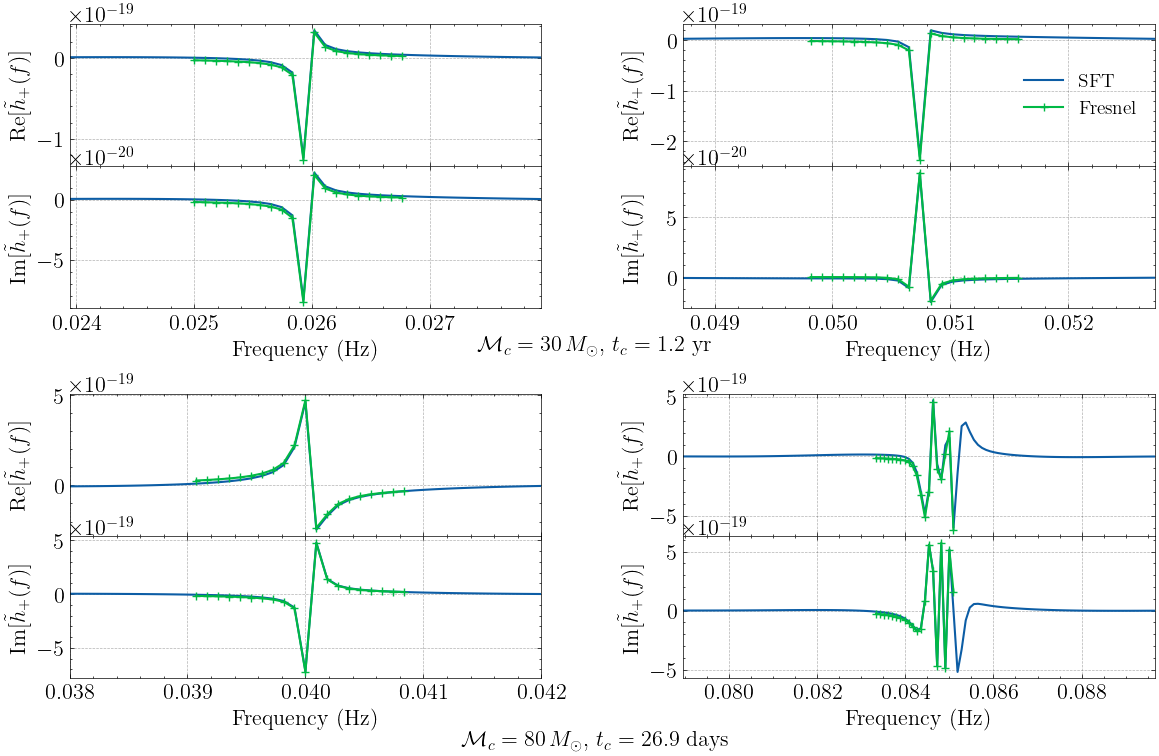

In [63]:

# ============================================================
# Row 1: Slowly evolving  (Mc=30 Msun, tc=1.2 yr, Tobs=1 yr)
# Row 2: Rapidly evolving (Mc=80 Msun, f0=0.04 Hz (derived tc))
# Col 1: First segment | Col 2: Leaving-band segment
# ============================================================

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

fig = plt.figure(figsize=(14, 8.5))
# Outer grid: 2 rows (one per source) with gap between them
outer_gs = GridSpec(2, 1, figure=fig, hspace=0.3)

# Inner grids: 2 rows each (Re + Im) with no gap
inner_gs = []
for i in range(2):
    igs = GridSpecFromSubplotSpec(2, 2, subplot_spec=outer_gs[i], hspace=0.0, wspace=0.3)
    inner_gs.append(igs)

dT_seg = 3 * 60 * 60   # 3-hour SFT segments
dt_s   = 5              # 5 s sampling cadence

# Case 2: Mc=80 Msun starting at f0=0.05 Hz
# Compute time to merger from f0=0.05 Hz
Mc_case2 = 80 * M_sun
f0_case2 = 0.04  # Hz
tc_case2 = time_to_merger(Mc_case2, f0_case2)  # seconds from f0 to merger

configs = [
    {"label": r"$\mathcal{M}_c=30\,M_\odot$, $\tau_c=1.2$ yr",
     "Mc": 30 * M_sun, "tc_s": 1.2 * YRSID_SI},
    {"label": r"$\mathcal{M}_c=80\,M_\odot$, $f_0=0.05$ Hz",
     "Mc": 80 * M_sun, "tc_s": tc_case2},
]

# Store all axes for label alignment
all_re_axes = []
all_im_axes = []

for ci, cfg in enumerate(configs):
    Mc_v  = cfg["Mc"]
    DL_v  = 100e6 * pc
    tc_v  = cfg["tc_s"]

    t_max = min(YRSID_SI, tc_v - 500)

    # ---------- generate waveform ----------
    t_arr   = np.arange(0, t_max, dt_s)
    f_arr   = freq(Mc_v, tc_v, t_arr)
    A_arr   = Amp(Mc_v, DL_v, f_arr)
    phi_arr = phase(Mc_v, t_arr, tc_v, 0)
    hp_arr  = A_arr * np.cos(phi_arr)

    # ---------- TF grid ----------
    tg, fg = setup_tf_grid(t_max, dt_s, dT_seg)
    f_nyq  = 1.0 / (2 * dt_s)

    # === select segments ===
    i_first = 0

    i_last = len(tg) - 2
    for ii in range(len(tg) - 2, -1, -1):
        f_start = freq(Mc_v, tc_v, tg[ii])
        if f_start < 0.85 * f_nyq:
            i_last = ii
            break

    for si, (seg_i, sname) in enumerate([
        (i_first, "First segment"),
        (i_last,  "Leaving-band segment"),
    ]):
        t0  = tg[seg_i]
        t1  = tg[seg_i + 1]

        # --- segment data ---
        mask   = (t_arr >= t0) & (t_arr < t1)
        hp_seg = hp_arr[mask]

        f0          = freq(Mc_v, tc_v, t0)
        fd0         = f_dot(Mc_v, tc_v, t0)
        df_sweep    = fd0 * dT_seg
        nbins_swept = fd0 * dT_seg**2 # fdot*dT = change in frequency then change_frequency/frequency space = number of bins swept

        # ---- Create subplot pair (Re on top, Im on bottom) ----
        ax_re = fig.add_subplot(inner_gs[ci][0, si])   # Real part
        ax_im = fig.add_subplot(inner_gs[ci][1, si])   # Imaginary part
        
        # Share x-axis between Re and Im
        ax_im.sharex(ax_re)
        ax_re.tick_params(labelbottom=False)
        
        # Store axes for label alignment
        all_re_axes.append(ax_re)
        all_im_axes.append(ax_im)
        
        # ---- FD panel ----
        win = scipy.signal.windows.tukey(len(hp_seg), alpha=0.05)
        h_sft = np.fft.rfft(hp_seg * win) * dt_s

        # Fresnel approximation
        hfr, ffr = h_fresnel(Mc_v, 
                             DL_v, 
                             tc_v, 
                             0, # phi c 
                             t0, 
                             t1, 
                             fg, # freqs 
                             bins=10) # 10 either side of central frequency 

        # xlim: centred on f0 with adaptive margin
        margin = max(0.002, df_sweep * 5)
        xlim_min = max(fg[0], f0 - margin)
        xlim_max = min(fg[-1], f0 + margin)
        
        # Plot Real parts
        ax_re.plot(fg, np.real(h_sft)[1:], "C0", lw=1.5, ls="-", label="SFT")
        ax_re.plot(ffr, np.real(hfr), "C1", lw=1.5, ls="-", label="Fresnel",marker='+')
        ax_re.set_xlim(xlim_min, xlim_max)
        ax_re.set_ylabel(r"$\mathrm{Re}[\tilde{h}_+(f)]$")
        ax_re.grid(alpha=0.3)
        
        # Plot Imaginary parts
        ax_im.plot(fg, np.imag(h_sft)[1:], "C0", lw=1.5, ls="-", label="SFT")
        ax_im.plot(ffr, np.imag(hfr), "C1", lw=1.5, ls="-", label="Fresnel",marker='+')
        ax_im.set_xlim(xlim_min, xlim_max)
        ax_im.set_xlabel("Frequency (Hz)")
        ax_im.set_ylabel(r"$\mathrm{Im}[\tilde{h}_+(f)]$")
        ax_im.grid(alpha=0.3)
        
        # Only show legend on top-right Re panel
        if ci == 0 and si == 1:
            ax_re.legend(fontsize=14, loc='center right')

# Align y-axis labels
fig.align_ylabels(all_re_axes)
fig.align_ylabels(all_im_axes)

# Add text annotations for each binary
# First source
fig.text(0.5, 0.495, r'$\mathcal{M}_c = 30\,M_\odot$, $t_c = 1.2$ yr', 
         ha='center', fontsize=16, transform=fig.transFigure)

# Second source
tc_case2_days = tc_case2 / (24 * 3600)
fig.text(0.5, 0.03, rf'$\mathcal{{M}}_c = 80\,M_\odot$, $t_c = {tc_case2_days:.1f}$ days', 
         ha='center', fontsize=16, transform=fig.transFigure)

plt.savefig('Validity_of_fresnel.pdf')
plt.show()
